In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
from scipy import optimize
from scipy.special import ndtr as norm_cdf

import xmltodict
import pandas as pd

In [2]:
%matplotlib widget

In [3]:
directory = '/home/sthoma/tokamak_inversion_routines/mastu/Calibration/Calib_2024_Nov_04/Lights_TS/'

In [4]:
x = np.linspace(0, 1023, 1024)
y = np.linspace(0, 1023, 1024)
xgrid, ygrid = np.meshgrid(x, y)

In [5]:
from mastu import HSV
vignette = HSV.vignette().T[:,::-1]
vignette /= vignette.max()

0 184
0 133
0 134


Text(0, 0.5, 'pixel #')

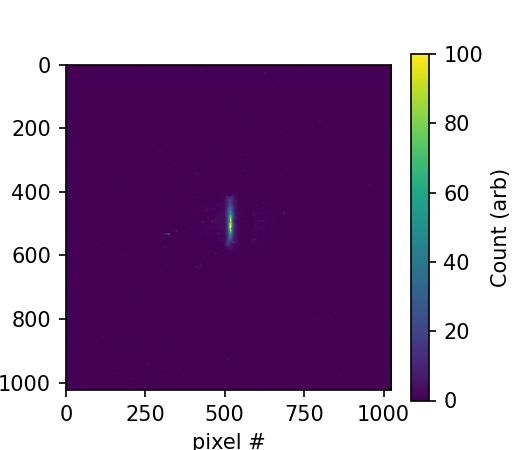

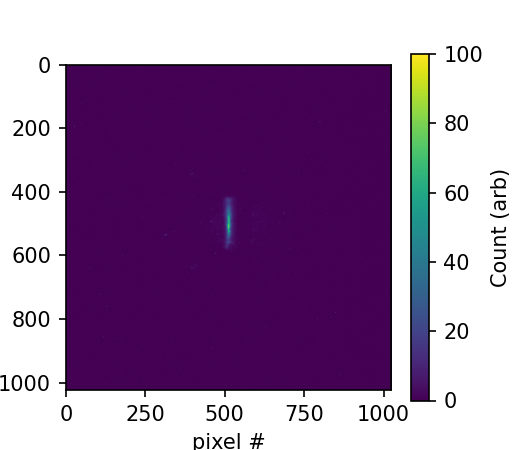

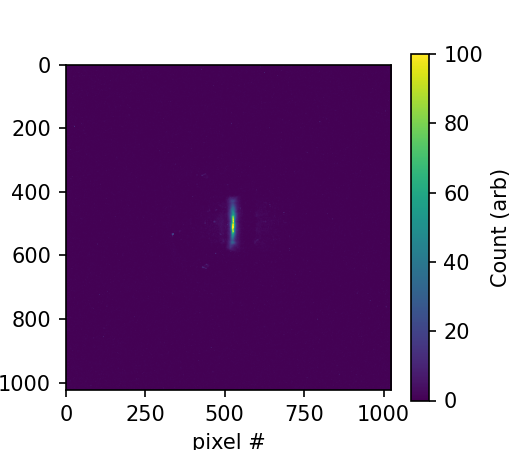

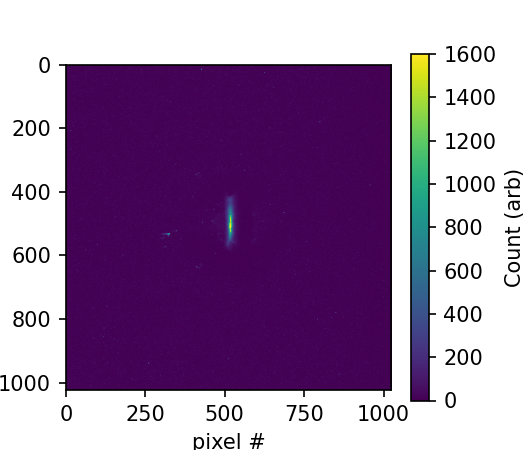

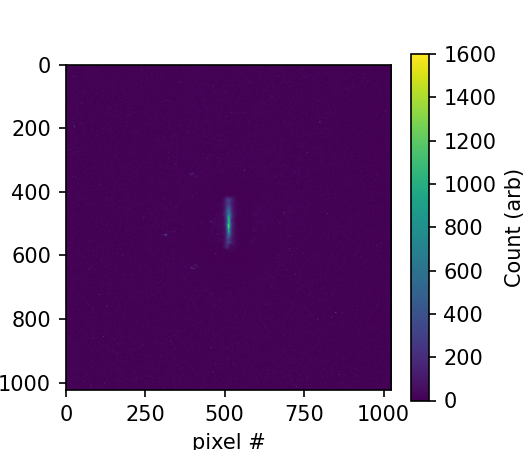

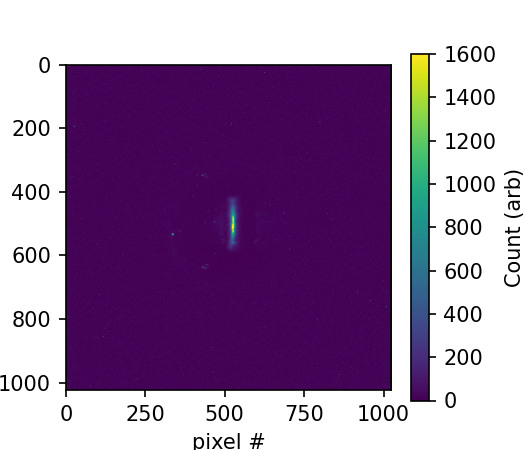

In [6]:
### central view
imgA = cv2.imread(directory + 'Camera_central.bmp', cv2.IMREAD_UNCHANGED).T[:,::-1]
print(imgA.min(), imgA.max())
imgB = cv2.imread(directory + 'Camera_left_facing_right.bmp', cv2.IMREAD_UNCHANGED).T[:,::-1]
print(imgB.min(), imgB.max())
imgC = cv2.imread(directory + 'Camera_right_facing_left.bmp', cv2.IMREAD_UNCHANGED).T[:,::-1]
print(imgC.min(), imgC.max())

vmin = 0
vmax = 100

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ims=ax.imshow(imgA, vmin=vmin, vmax=vmax, cmap=plt.cm.viridis)
fig.colorbar(ims, ax=ax, label='Count (arb)')
ax.set_xlabel('pixel #')
ax.set_ylabel('pixel #')

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ims=ax.imshow(imgB, vmin=vmin, vmax=vmax, cmap=plt.cm.viridis)
fig.colorbar(ims, ax=ax, label='Count (arb)')
ax.set_xlabel('pixel #')
ax.set_ylabel('pixel #')

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ims=ax.imshow(imgC, vmin=vmin, vmax=vmax, cmap=plt.cm.viridis)
fig.colorbar(ims, ax=ax, label='Count (arb)')
ax.set_xlabel('pixel #')
ax.set_ylabel('pixel #')

imgA = imgA * 16. / vignette
imgB = imgB * 16. / vignette
imgC = imgC * 16. / vignette

vmax = 100 * 16. / vignette.max()

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ims=ax.imshow(imgA, vmin=vmin, vmax=vmax, cmap=plt.cm.viridis)
fig.colorbar(ims, ax=ax, label='Count (arb)')
ax.set_xlabel('pixel #')
ax.set_ylabel('pixel #')

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ims=ax.imshow(imgB, vmin=vmin, vmax=vmax, cmap=plt.cm.viridis)
fig.colorbar(ims, ax=ax, label='Count (arb)')
ax.set_xlabel('pixel #')
ax.set_ylabel('pixel #')

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ims=ax.imshow(imgC, vmin=vmin, vmax=vmax, cmap=plt.cm.viridis)
fig.colorbar(ims, ax=ax, label='Count (arb)')
ax.set_xlabel('pixel #')
ax.set_ylabel('pixel #')

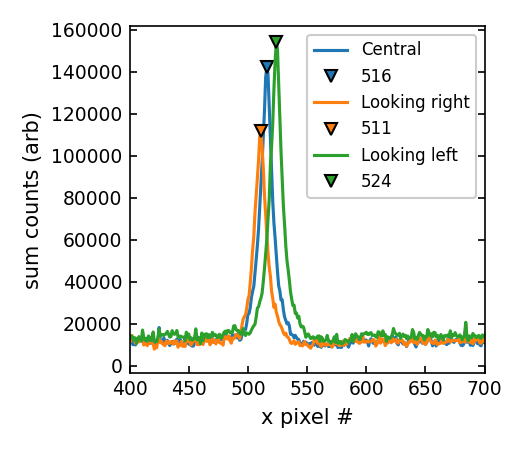

In [7]:
sumA = np.sum(imgA, axis=0)
sumB = np.sum(imgB, axis=0)
sumC = np.sum(imgC, axis=0)
indA = sumA.argmax()
indB = sumB.argmax()
indC = sumC.argmax()

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot(x, sumA, c='C0', label='Central')
ax.plot(x[indA], sumA[indA], 'v', c='C0', mec='k', label=indA)
ax.plot(x, sumB, c='C1', label='Looking right')
ax.plot(x[indB], sumB[indB], 'v', c='C1', mec='k', label=indB)
ax.plot(x, sumC, c='C2', label='Looking left')
ax.plot(x[indC], sumC[indC], 'v', c='C2', mec='k', label=indC)
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.set_xlabel('x pixel #')
ax.set_ylabel('sum counts (arb)')
ax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
          left=True, bottom=True, right=True, top=False)
ax.set_xlim([400,700])
plt.tight_layout()

In [8]:
def RMS(data, fit):
    return np.sqrt(np.mean((data - fit)**2))

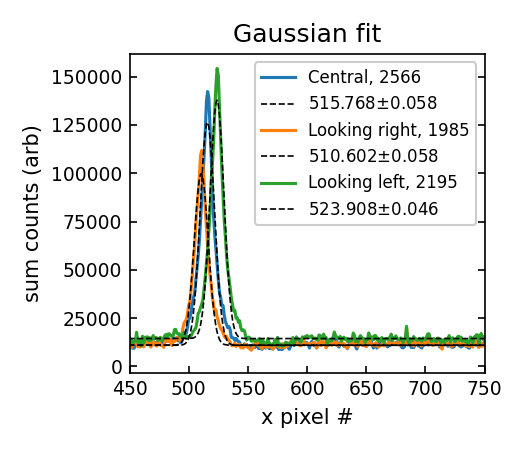

In [9]:
def gauss(x, A, x0, s, C):
    return A * np.exp(-0.5 * (x - x0)**2 / (2. * s**2)) + C

p0 = (140000., 520., 6., 600.)
sf = 2

poptA, pcovA = optimize.curve_fit(gauss, x, sumA, p0=p0)
pcovA = np.sqrt(np.diag(pcovA))
dpA = sf - int(np.floor(np.log10(pcovA[1]))) - 1
yA = gauss(x, *poptA)
rmsA = RMS(sumA, yA)
poptB, pcovB = optimize.curve_fit(gauss, x, sumB, p0=p0)
pcovB = np.sqrt(np.diag(pcovB))
dpB = sf - int(np.floor(np.log10(pcovB[1]))) - 1
yB = gauss(x, *poptB)
rmsB = RMS(sumB, yB)
poptC, pcovC = optimize.curve_fit(gauss, x, sumC, p0=p0)
pcovC = np.sqrt(np.diag(pcovC))
dpC = sf - int(np.floor(np.log10(pcovC[1]))) - 1
yC = gauss(x, *poptC)
rmsC = RMS(sumC, yC)

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot(x, sumA, c='C0', label=f'Central, {rmsA:.0f}', zorder=1)
ax.plot(x, yA, '--', c='k', lw=0.8, zorder=2, 
        label=f'{poptA[1]:.{dpA}f}$\\pm${pcovA[1]:.{dpA}f}')
ax.plot(x, sumB, c='C1', label=f'Looking right, {rmsB:.0f}', zorder=1)
ax.plot(x, yB, '--', c='k', lw=0.8, zorder=2, 
        label=f'{poptB[1]:.{dpB}f}$\\pm${pcovB[1]:.{dpB}f}')
ax.plot(x, sumC, c='C2', label=f'Looking left, {rmsC:.0f}', zorder=1)
ax.plot(x, yC, '--', c='k', lw=0.8, zorder=2, 
        label=f'{poptC[1]:.{dpC}f}$\\pm${pcovC[1]:.{dpC}f}')
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.set_xlabel('x pixel #')
ax.set_ylabel('sum counts (arb)')
ax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
          left=True, bottom=True, right=True, top=False)
ax.set_xlim([450,750])
ax.title.set_text('Gaussian fit')
plt.tight_layout()

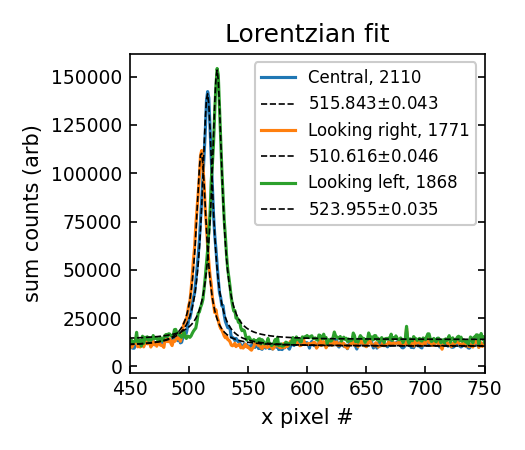

In [10]:
def lorentzian(x, A, x0, g, C):
    return A / (g * (1. + ((x - x0) / g)**2)) + C

p0 = (140000., 520., 65., 600.)
sf = 2

popt1, pcov1 = optimize.curve_fit(lorentzian, x, sumA, p0=p0)
pcov1 = np.sqrt(np.diag(pcov1))
dp1 = sf - int(np.floor(np.log10(pcov1[1]))) - 1
y1 = lorentzian(x, *popt1)
rms1 = RMS(sumA, y1)
popt2, pcov2 = optimize.curve_fit(lorentzian, x, sumB, p0=p0)
pcov2 = np.sqrt(np.diag(pcov2))
dp2 = sf - int(np.floor(np.log10(pcov2[1]))) - 1
y2 = lorentzian(x, *popt2)
rms2 = RMS(sumB, y2)
popt3, pcov3 = optimize.curve_fit(lorentzian, x, sumC, p0=p0)
pcov3 = np.sqrt(np.diag(pcov3))
dp3 = sf - int(np.floor(np.log10(pcov3[1]))) - 1
y3 = lorentzian(x, *popt3)
rms3 = RMS(sumC, y3)

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot(x, sumA, c='C0', label=f'Central, {rms1:.0f}', zorder=1)
ax.plot(x, y1, '--', c='k', lw=0.8, zorder=2, 
        label=f'{popt1[1]:.{dp1}f}$\\pm${pcov1[1]:.{dp1}f}')
ax.plot(x, sumB, c='C1', label=f'Looking right, {rms2:.0f}', zorder=1)
ax.plot(x, y2, '--', c='k', lw=0.8, zorder=2, 
        label=f'{popt2[1]:.{dp2}f}$\\pm${pcov2[1]:.{dp2}f}')
ax.plot(x, sumC, c='C2', label=f'Looking left, {rms3:.0f}', zorder=1)
ax.plot(x, y3, '--', c='k', lw=0.8, zorder=2, 
        label=f'{popt3[1]:.{dp3}f}$\\pm${pcov3[1]:.{dp3}f}')
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.set_xlabel('x pixel #')
ax.set_ylabel('sum counts (arb)')
ax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
          left=True, bottom=True, right=True, top=False)
ax.set_xlim([450,750])
ax.title.set_text('Lorentzian fit')
plt.tight_layout()

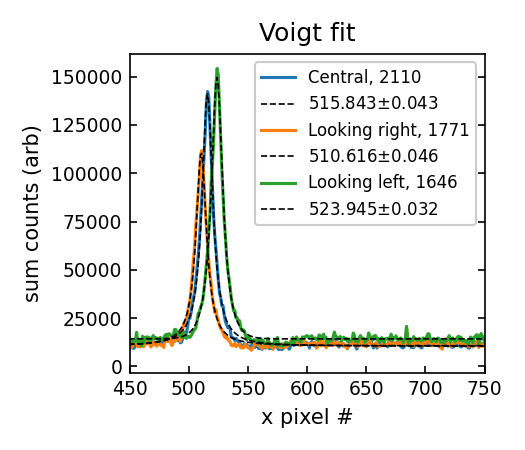

In [11]:
def voigt(x, A, x0, s, g, C):
    G = np.exp(-0.5 * (x - x0)**2 / (2. * s**2))
    L = g / (g**2 + (x - x0)**2)
    return A * G * L + C

p0 = (100000., 520., 5., 5., 600.)
sf = 2

poptalpha, pcovalpha = optimize.curve_fit(voigt, x, sumA, p0=p0)
pcovalpha = np.sqrt(np.diag(pcovalpha))
dpalpha = sf - int(np.floor(np.log10(pcovalpha[1]))) - 1
yalpha = voigt(x, *poptalpha)
rmsalpha = RMS(sumA, yalpha)
poptbeta, pcovbeta = optimize.curve_fit(voigt, x, sumB, p0=p0)
pcovbeta = np.sqrt(np.diag(pcovbeta))
dpbeta = sf - int(np.floor(np.log10(pcovbeta[1]))) - 1
ybeta = voigt(x, *poptbeta)
rmsbeta = RMS(sumB, ybeta)
poptgamma, pcovgamma = optimize.curve_fit(voigt, x, sumC, p0=p0)
pcovgamma = np.sqrt(np.diag(pcovgamma))
dpgamma = sf - int(np.floor(np.log10(pcovgamma[1]))) - 1
ygamma = voigt(x, *poptgamma)
rmsgamma = RMS(sumC, ygamma)

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot(x, sumA, c='C0', label=f'Central, {rmsalpha:.0f}', zorder=1)
ax.plot(x, yalpha, '--', c='k', lw=0.8, zorder=2, 
        label=f'{poptalpha[1]:.{dpalpha}f}$\\pm${pcovalpha[1]:.{dpalpha}f}')
ax.plot(x, sumB, c='C1', label=f'Looking right, {rmsbeta:.0f}', zorder=1)
ax.plot(x, ybeta, '--', c='k', lw=0.8, zorder=2, 
        label=f'{poptbeta[1]:.{dpbeta}f}$\\pm${pcovbeta[1]:.{dpbeta}f}')
ax.plot(x, sumC, c='C2', label=f'Looking left, {rmsgamma:.0f}', zorder=1)
ax.plot(x, ygamma, '--', c='k', lw=0.8, zorder=2, 
        label=f'{poptgamma[1]:.{dpgamma}f}$\\pm${pcovgamma[1]:.{dpgamma}f}')
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.set_xlabel('x pixel #')
ax.set_ylabel('sum counts (arb)')
ax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
          left=True, bottom=True, right=True, top=False)
ax.set_xlim([450,750])
ax.title.set_text('Voigt fit')
plt.tight_layout()

In [12]:
print(rmsA, rms1, rmsalpha)
print(np.min([rmsA, rms1, rmsalpha]))

2565.818866844033 2109.9315977487868 2109.9316195568267
2109.9315977487868


In [13]:
print(rmsB, rms2, rmsbeta)
print(np.min([rmsB, rms2, rmsbeta]))

1985.3278989222092 1770.8730790712666 1770.8730919526513
1770.8730790712666


In [14]:
print(rmsC, rms3, rmsgamma)
print(np.min([rmsC, rms3, rmsgamma]))

2195.2641008960522 1867.574473129861 1646.2356457869985
1646.2356457869985


In [15]:
poptA[1], popt1[1], poptalpha[1]

(515.7684940121126, 515.8433207894701, 515.8433176806434)

In [16]:
poptB[1], popt2[1], poptbeta[1]

(510.6023068205751, 510.6158715932333, 510.6158701155263)

In [17]:
poptC[1], popt3[1], poptgamma[1]

(523.9079299698958, 523.9549782430889, 523.9450756092879)

In [18]:
import my_funcs as mf

-------------------Loading module Divertor-------------------
-------------------Loading module Utilities-------------------
kk_cz couldnt be imported (SyntaxError)
dd couldnt be imported


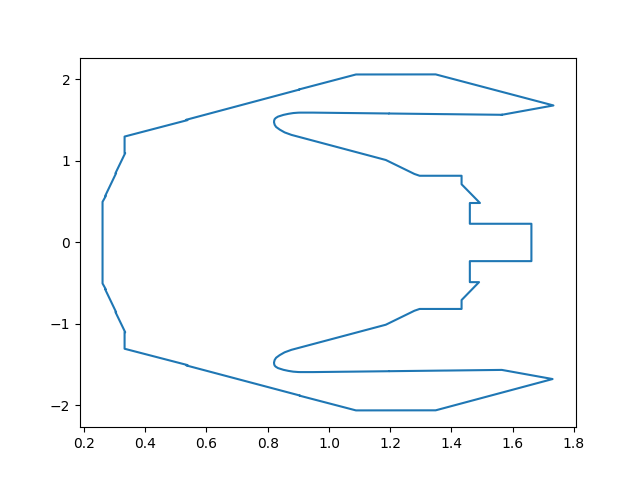

In [19]:
Rlim, zlim = mf.getLimiter()
plt.figure()
plt.plot(Rlim, zlim)